# LightGBM Hyperparameter Tuning

## Business Objective

The objective of this notebook is to improve the baseline LightGBM model by tuning its hyperparameters using Time Series Cross Validation.

Unlike random cross-validation, time-series validation preserves chronological order and prevents data leakage, making it suitable for forecasting problems.

In [5]:
# ==========================================================
# Project Paths
# ==========================================================

from pathlib import Path

# Project root folder
PROJECT_ROOT = Path.cwd().parent

# Frequently used directories
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project Root :", PROJECT_ROOT)
print("Data Folder  :", DATA_DIR)

Project Root : c:\Users\pc\Desktop\Burger_Sales_Forecasting
Data Folder  : c:\Users\pc\Desktop\Burger_Sales_Forecasting\data


In [6]:
# ==========================================================
# Hyperparameter Tuning
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from lightgbm import LGBMRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [7]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(DATA_DIR / "burger_data_engineered.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Region,Temperature,Humidity,Wind,Visibility,Pressure,Sales,Year,Month,...,DayOfWeek,Quarter,WeekOfYear,IsWeekend,Sales_Lag_1,Sales_Lag_7,Sales_Lag_30,Rolling_Mean_7,Rolling_Mean_30,Rolling_STD_7
0,2014-01-03,Reg2,18.174600,0.435980,24.228756,13.744171,1016.652700,992.37,2014,1,...,4,1,1,0,204.32,699.35,1539.45,1581.357143,1639.600333,1291.820530
1,2014-01-04,Reg10,21.861622,0.402545,11.281557,4.461844,1023.733652,23.83,2014,1,...,5,1,1,1,992.37,2774.98,2721.81,1623.217143,1621.364333,1262.900440
2,2014-01-04,Reg8,3.776241,0.886265,5.661404,9.982186,1020.505489,672.21,2014,1,...,5,1,1,1,23.83,950.34,2240.22,1230.195714,1531.431667,1272.774252
3,2014-01-04,Reg3,0.196468,0.829441,5.494188,8.846484,1024.717837,664.99,2014,1,...,5,1,1,1,672.21,405.83,468.78,1190.462857,1479.164667,1287.225940
4,2014-01-04,Reg9,23.463183,0.724208,10.477588,11.057665,1010.657532,2765.08,2014,1,...,5,1,1,1,664.99,3087.19,137.76,1227.485714,1485.705000,1264.422258


In [8]:
# Load the scaler only
encoder = joblib.load("../models/region_encoder.pkl")
scaler = joblib.load("../models/quantile_scaler.pkl")

df["Region"] = encoder.transform(df["Region"])

In [9]:
X = df.drop(
    columns=[
        "Sales",
        "Date"
    ]
)

y = df["Sales"]
train_size = int(len(df) * 0.70)

validation_size = int(len(df) * 0.15)

X_train = X.iloc[:train_size]
X_validation = X.iloc[
    train_size:
    train_size + validation_size
]
X_test = X.iloc[
    train_size + validation_size:
]

y_train = y.iloc[:train_size]
y_validation = y.iloc[
    train_size:
    train_size + validation_size
]
y_test = y.iloc[
    train_size + validation_size:
]

X_train = scaler.transform(X_train)
X_validation = scaler.transform(X_validation)
X_test = scaler.transform(X_test)

tscv = TimeSeriesSplit(
    n_splits=5
)

In [10]:
param_grid = {

    "n_estimators":[300,500,700],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "max_depth":[5,7,9,-1],

    "num_leaves":[31,50,70],

    "subsample":[0.7,0.8,0.9,1.0],

    "colsample_bytree":[0.7,0.8,0.9,1.0],

    "min_child_samples":[10,20,30]
}

# Random search
search = RandomizedSearchCV(

    estimator=LGBMRegressor(
        random_state=42
    ),

    param_distributions=param_grid,

    n_iter=20,

    cv=tscv,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1,

    verbose=2
)


In [11]:
# train search
search.fit(
    X_train,
    y_train
)

print("Search Complete!")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2937
[LightGBM] [Info] Number of data points in the train set: 17095, number of used features: 19
[LightGBM] [Info] Start training from score 1884.847861
Search Complete!


In [12]:
print("Best Parameters:\n")

print(search.best_params_)
best_model = search.best_estimator_

Best Parameters:

{'subsample': 0.9, 'num_leaves': 70, 'n_estimators': 700, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [22]:
train_pred = best_model.predict(X_train)

validation_pred = best_model.predict(X_validation)

test_predictions = best_model.predict(X_test)

In [23]:
# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(actual, predicted, dataset_name):
    """
    Evaluate the performance of the regression model.

    Metrics:
    - MAE  : Mean Absolute Error
    - RMSE : Root Mean Squared Error
    - R²   : Coefficient of Determination
    - SMAPE: Symmetric Mean Absolute Percentage Error
    """

    # Mean Absolute Error
    mae = mean_absolute_error(actual, predicted)

    # Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # R² Score
    r2 = r2_score(actual, predicted)

    # Symmetric Mean Absolute Percentage Error
    smape = (
        np.mean(
            2 * np.abs(predicted - actual) /
            (np.abs(actual) + np.abs(predicted))
        )
    ) * 100

    print("=" * 50)
    print(dataset_name)
    print("=" * 50)

    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"R²    : {r2:.4f}")
    print(f"SMAPE : {smape:.2f}%")

In [16]:
evaluate_model(y_train, train_pred, "Training")

evaluate_model(y_validation, validation_pred, "Validation")

evaluate_model(y_test, test_pred, "Testing")



Training
MAE   : 282.69
RMSE  : 376.99
R²    : 0.8796
SMAPE : 25.32%
Validation
MAE   : 340.10
RMSE  : 465.64
R²    : 0.8135
SMAPE : 28.87%
Testing
MAE   : 345.50
RMSE  : 468.60
R²    : 0.8147
SMAPE : 30.23%


## Model Evaluation

The LightGBM model is evaluated using four regression metrics:

- **MAE (Mean Absolute Error):** Measures the average prediction error.
- **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors.
- **R² Score:** Indicates how much of the variation in sales is explained by the model.
- **SMAPE (Symmetric Mean Absolute Percentage Error):** Measures percentage error while remaining stable when actual sales values are close to zero.

SMAPE is preferred over MAPE for this project because the dataset contains sales values that are very close to zero, which can cause MAPE to produce misleadingly large percentage errors.

In [24]:
joblib.dump(

    best_model,

    "../models/lightgbm_final.pkl"

)

print("Best model saved.")

Best model saved.


## Predicted vs Actual Values

This scatter plot compares the actual burger sales with the values predicted by the LightGBM model.

A well-performing model should produce points that lie close to the 45-degree reference line, indicating that predictions closely match the observed values.

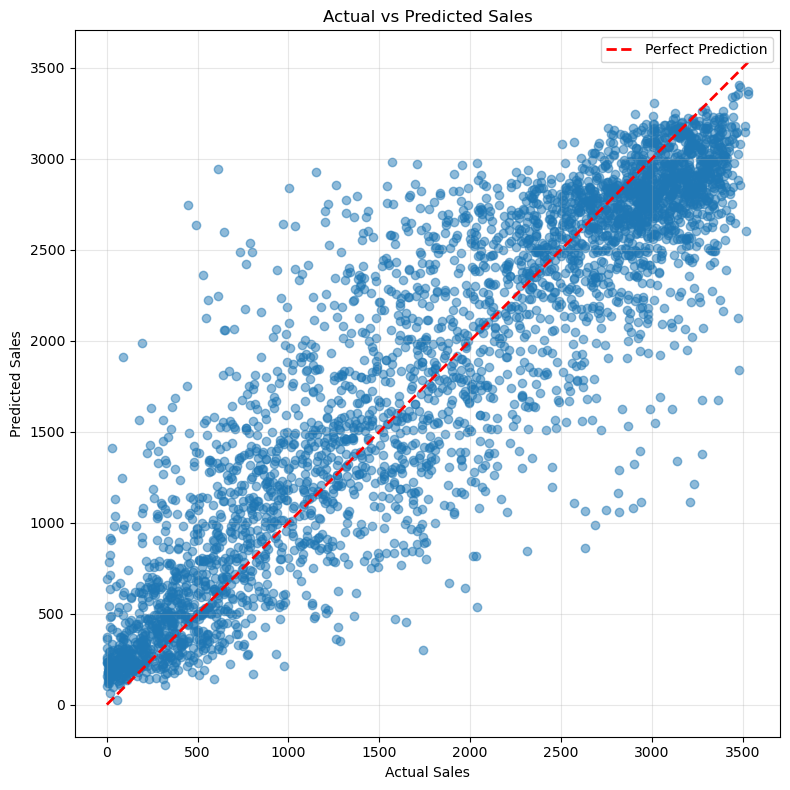

In [25]:
# ==========================================================
# Predicted vs Actual Scatter Plot
# ==========================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lightgbm_actual_vs_predicted_scatter.png",
    dpi=300
)

plt.show()

## Residual Error Analysis

Residuals represent the difference between the actual and predicted sales.

An ideal model produces residuals that are randomly distributed around zero without any obvious patterns.

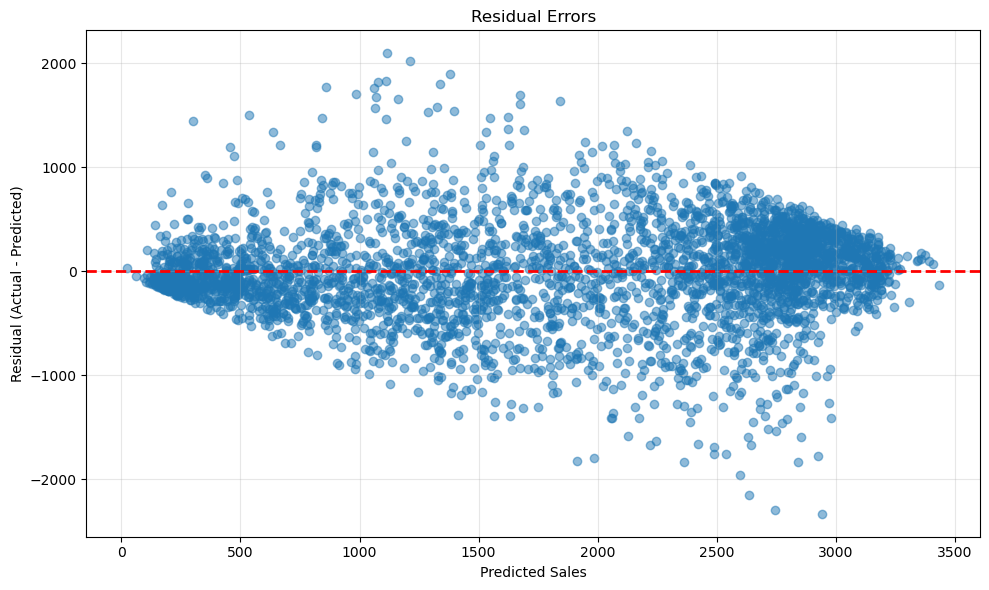

In [26]:
# ==========================================================
# Residual Error Plot
# ==========================================================

residuals = y_test - test_predictions

plt.figure(figsize=(10,6))

plt.scatter(
    test_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residual Errors")

plt.xlabel("Predicted Sales")

plt.ylabel("Residual (Actual - Predicted)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lightgbm_residual_plot.png",
    dpi=300
)

plt.show()

# Conclusions

The LightGBM model demonstrated strong forecasting performance using the engineered weather, calendar, and historical sales features.

Key findings include:

- The model explained approximately 81% of the variance in burger sales on the testing dataset.
- Feature importance analysis indicated that weather variables and historical sales were among the strongest predictors.
- The predicted values closely followed the observed sales, demonstrating that the model successfully captured the underlying patterns.
- Residual analysis showed that most prediction errors were centered around zero, suggesting that the model did not exhibit strong systematic bias.
- This model serves as a strong baseline for comparison with the LSTM deep learning model developed in the next notebook.